## Diagnostics: Argument Error Composition

This section reads `evaluation_mismatch_diagnostics.csv` from the same
top-level strategy directories. The denominator is all `argument_mismatch` rows
for the same `domain + model + strategy`.

Two high-signal diagnostic families are shown:
- split head/modifier words: `unnecessary_head_or_modifier_split`
- preposition arguments: `preposition_object` or `preposition_argument`

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from eval.read_eval import (
    DOMAIN_LABELS,
    DOMAIN_ORDER,
    METHOD_LABELS,
    METHOD_ORDER,
    MODEL_LABELS,
    MODEL_ORDER,
    read_diagnostics_by_mismatch_type,
)
from utils.helpers import find_project_root
import matplotlib.colors as mcolors


ROOT = find_project_root()
RESULT_ROOT = ROOT / "results"

DIAGNOSTIC_ISSUES = {
    "Split head/modifier": ["unnecessary_head_or_modifier_split"],
    "Preposition arg": ["preposition_object", "preposition_argument"],
}

diagnostics_df = read_diagnostics_by_mismatch_type(
    RESULT_ROOT,
    domain_labels=DOMAIN_LABELS,
    method_labels=METHOD_LABELS,
    model_order=MODEL_ORDER,
    mismatch_type="argument_mismatch"
)


In [3]:
rows = []
for (domain, method, model), group in diagnostics_df.groupby(
    ["domain", "method", "model"], observed=True
):
    arg_errors = len(group)
    issue_text = group["issue_text"].fillna("")

    for issue, needles in DIAGNOSTIC_ISSUES.items():
        count = issue_text.str.contains("|".join(needles), regex=True, na=False).sum()
        rows.append(
            {
                "domain": domain,
                "method": method,
                "model": model,
                "issue": issue,
                "count": int(count),
                "arg_errors": int(arg_errors),
                "share": count / arg_errors if arg_errors else np.nan,
            }
        )

diag_issue_share_df = pd.DataFrame(rows).sort_values(
    ["issue", "domain", "model", "method"]
)
display(diag_issue_share_df.head(5))


,domain,method,model,issue,count,arg_errors,share
31,cooking,nl2p_1,gemma3-12b,Preposition arg,431,1076,0.400558
41,cooking,nl2p_1_ablation,gemma3-12b,Preposition arg,408,1061,0.384543
51,cooking,nl2p_1_coref,gemma3-12b,Preposition arg,430,1061,0.405278
33,cooking,nl2p_1,gemma3-27b,Preposition arg,317,897,0.353400
43,cooking,nl2p_1_ablation,gemma3-27b,Preposition arg,383,1074,0.356611


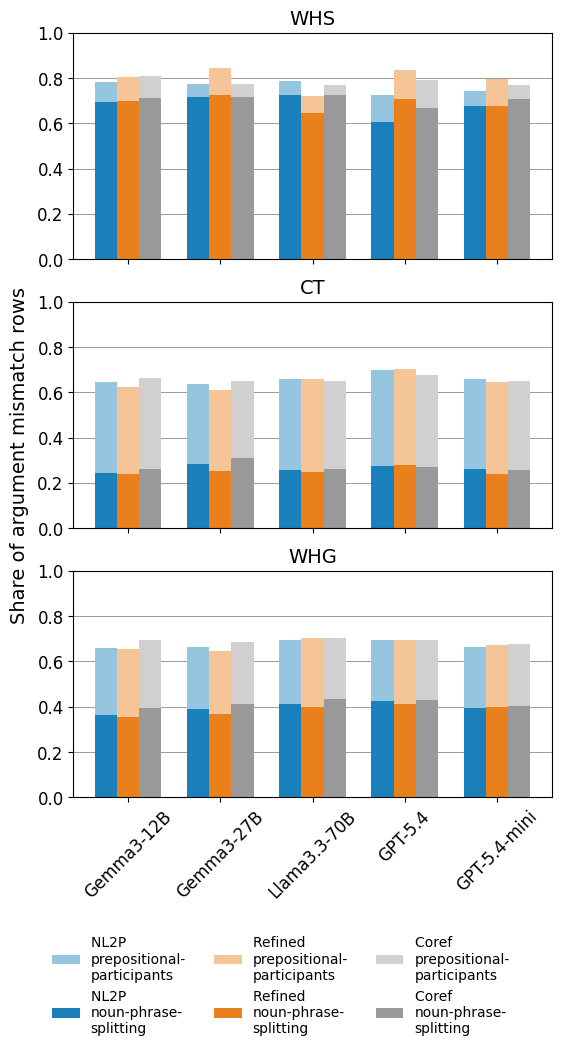

In [ ]:
colors = ["#1a80bb", "#ea801c", "#999999"]
method_colors = {
    "nl2p_1": "#1a80bb",
    "nl2p_1_ablation": "#ea801c",
    "nl2p_1_coref": "#999999",
}
method_offsets = {
    "nl2p_1": -0.24,
    "nl2p_1_ablation": 0.0,
    "nl2p_1_coref": 0.24,
}
issues = list(DIAGNOSTIC_ISSUES)
models = [model for model in MODEL_ORDER if model in set(diag_issue_share_df["model"].astype(str))]
model_labels = [MODEL_LABELS.get(model, model) for model in models]

def lighten(hex_color, alpha=0.543):
    r, g, b = mcolors.to_rgb(hex_color)

    r = r * (1 - alpha) + 1.0 * alpha
    g = g * (1 - alpha) + 1.0 * alpha
    b = b * (1 - alpha) + 1.0 * alpha

    return mcolors.to_hex((r, g, b))

# --- Font Size Configuration ---
TITLE_SIZE = 14
LABEL_SIZE = 14
TICK_LABEL_SIZE = 12
LEGEND_SIZE = 12

fig, axes = plt.subplots(
    nrows=len(DOMAIN_ORDER),
    ncols=1,
    figsize=(5.5, 9.0),
    sharex=True,
    sharey=True,
    constrained_layout=True,
)

fig.supylabel("Share of argument mismatch rows", fontsize=LABEL_SIZE)

x = np.arange(len(models))
width = 0.24
stack_max = diag_issue_share_df.groupby(["domain", "method", "model"], observed=True)["share"].sum().max()
y_max = max(0.25, stack_max * 1.15 if pd.notna(stack_max) else 0.25)

for col_idx, domain in enumerate(DOMAIN_ORDER):
    ax = axes[col_idx]
    panel = diag_issue_share_df[diag_issue_share_df["domain"].astype(str) == domain]

    for method_key in METHOD_ORDER:
        bottom = np.zeros(len(models))
        for issue_idx, issue in enumerate(issues):
            values = []
            for model in models:
                row = panel[
                    (panel["method"].astype(str) == method_key)
                    & (panel["model"].astype(str) == model)
                    & (panel["issue"] == issue)
                ]
                values.append(0.0 if row.empty else float(row.iloc[0]["share"]))

            values = np.array(values)
            base_color = method_colors[method_key]
            
            # Use explicitly darker color for issue 0, and lighter color for issue 1. No hatch.
            bar_color = base_color if issue_idx == 0 else lighten(base_color)
            
            ax.bar(
                x + method_offsets[method_key],
                values,
                bottom=bottom,
                width=width,
                facecolor=bar_color,
                # edgecolor="white",
                linewidth=0.8,
            )
            bottom += values

    ax.set_title(DOMAIN_LABELS[domain], fontsize=TITLE_SIZE)
    ax.set_xticks(x)
    
    if col_idx == len(DOMAIN_ORDER) - 1:
        ax.set_xticklabels(model_labels, rotation=45, fontsize=TICK_LABEL_SIZE)
        
    ax.set_ylim(0.0, 1.0)
    ax.tick_params(axis='y', labelsize=TICK_LABEL_SIZE)
    ax.grid(axis="y", color="#595959", linewidth=0.6, alpha=0.7)
    ax.set_axisbelow(True)


LEGEND_LABELS = {
    ("nl2p_1", "Split head/modifier"): "NL2P \nnoun-phrase-splitting",
    ("nl2p_1", "Preposition arg"): "NL2P \nprepositional-participants",

    ("nl2p_1_ablation", "Split head/modifier"): "Refined \nnoun-phrase-splitting",
    ("nl2p_1_ablation", "Preposition arg"): "Refined \nprepositional-participants",

    ("nl2p_1_coref", "Split head/modifier"): "Coref \nnoun-phrase-splitting",
    ("nl2p_1_coref", "Preposition arg"): "Coref \nprepositional-participants",
}

handles = []
for method_key, color in zip(METHOD_ORDER, colors):
    for issue_idx, issue in enumerate(issues):
        bar_color = method_colors[method_key] if issue_idx == 0 else lighten(method_colors[method_key])
        
        handles.append(
            plt.Rectangle(
                (0, 0),
                1,
                1,
                facecolor=bar_color,
                # edgecolor="white",
                linewidth=0.8,
                label=LEGEND_LABELS.get(
                    (method_key, issue),
                    f"{METHOD_LABELS[method_key]} - {issue}",
                ),
            )
        )

# --- Manual Legend Ordering ---
# The default handles list has 6 items (3 methods x 2 issues).
# Indices are: 0 (Method1-Issue1), 1 (Method1-Issue2), 2 (Method2-Issue1), etc.
# Change this list to reorder them however you like:
manual_order = [1, 0, 3, 2, 5, 4]
ordered_handles = [handles[i] for i in manual_order]

fig.legend(
    handles=ordered_handles,
    loc="upper center",
    bbox_to_anchor=(0.5, -0.02),
    ncol=3,
    frameon=False,
    fontsize=LEGEND_SIZE,
)

plt.show()


In [5]:
table_source = diag_issue_share_df.assign(
    domain=diag_issue_share_df["domain"].astype(str).map(DOMAIN_LABELS),
    method=diag_issue_share_df["method"].astype(str).map(METHOD_LABELS),
    model_label=diag_issue_share_df["model"].astype(str).map(MODEL_LABELS).fillna(diag_issue_share_df["model"].astype(str)),
)
table_source["domain"] = pd.Categorical(
    table_source["domain"], [DOMAIN_LABELS[key] for key in DOMAIN_ORDER], ordered=True
)
table_source["method"] = pd.Categorical(
    table_source["method"], [METHOD_LABELS[key] for key in METHOD_ORDER], ordered=True
)

diag_issue_table = table_source.pivot_table(
    index=["issue", "method", "model_label"],
    columns="domain",
    values="share",
    aggfunc="first",
    observed=False,
)
display((diag_issue_table * 100).round(2))


domain                                      WHS     CT    WHG
issue               method  model_label                      
Preposition arg     NL2P-1  GPT-5.4       11.69  42.60  26.70
                            GPT-5.4-mini   6.58  39.69  27.01
                            Gemma3-12B     8.66  40.06  29.62
                            Gemma3-27B     5.95  35.34  27.38
                            Llama3.3-70B   5.88  40.25  28.21
                    Refined GPT-5.4       12.94  42.44  28.48
                            GPT-5.4-mini  11.55  40.34  27.47
                            Gemma3-12B    10.36  38.45  30.25
                            Gemma3-27B    11.87  35.66  27.61
                            Llama3.3-70B   7.58  41.15  30.79
                    Coref   GPT-5.4       12.11  40.59  26.39
                            GPT-5.4-mini   6.26  39.28  27.50
                            Gemma3-12B     9.63  40.53  30.25
                            Gemma3-27B     5.46  34.18  27.31
                            Llama3.3-70B   4.72  38.53  26.73
Split head/modifier NL2P-1  GPT-5.4       60.66  27.26  42.53
                            GPT-5.4-mini  67.69  26.06  39.30
                            Gemma3-12B    69.44  24.35  36.20
                            Gemma3-27B    71.57  28.43  38.76
                            Llama3.3-70B  72.61  25.63  41.09
                    Refined GPT-5.4       70.60  27.67  41.11
                            GPT-5.4-mini  67.78  24.04  39.68
                            Gemma3-12B    69.90  23.85  35.20
                            Gemma3-27B    72.36  25.33  36.96
                            Llama3.3-70B  64.35  24.58  39.62
                    Coref   GPT-5.4       66.81  26.97  42.90
                            GPT-5.4-mini  70.74  25.55  40.20
                            Gemma3-12B    71.10  25.92  39.40
                            Gemma3-27B    71.69  30.82  41.20
                            Llama3.3-70B  72.34  26.33  43.56